In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sample_retail.CSV.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

In [6]:
cohort = df.groupby("Customer ID")["InvoiceMonth"].min()

df["CohortMonth"] = df["Customer ID"].map(cohort)

In [8]:
df[["Customer ID","InvoiceMonth","CohortMonth"]].head()

,Customer ID,InvoiceMonth,CohortMonth
0,13085.0,2009-12,2009-12
1,13085.0,2009-12,2009-12
2,13085.0,2009-12,2009-12
3,13085.0,2009-12,2009-12
4,13085.0,2009-12,2009-12


In [10]:
def get_month_index(invoice_month, cohort_month):
    return (invoice_month.year - cohort_month.year) * 12 + (invoice_month.month - cohort_month.month) + 1

df["CohortIndex"] = df.apply(
    lambda row: get_month_index(row["InvoiceMonth"], row["CohortMonth"]),
    axis=1
)

In [12]:
cohort_data = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["Customer ID"].nunique().reset_index()

In [14]:
cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer ID"
)

In [15]:
retention = cohort_counts.divide(cohort_counts.iloc[:, 0], axis=0) * 100

In [16]:
retention.round(2)

CohortIndex,1.0
CohortMonth,
2009-12,100.0


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

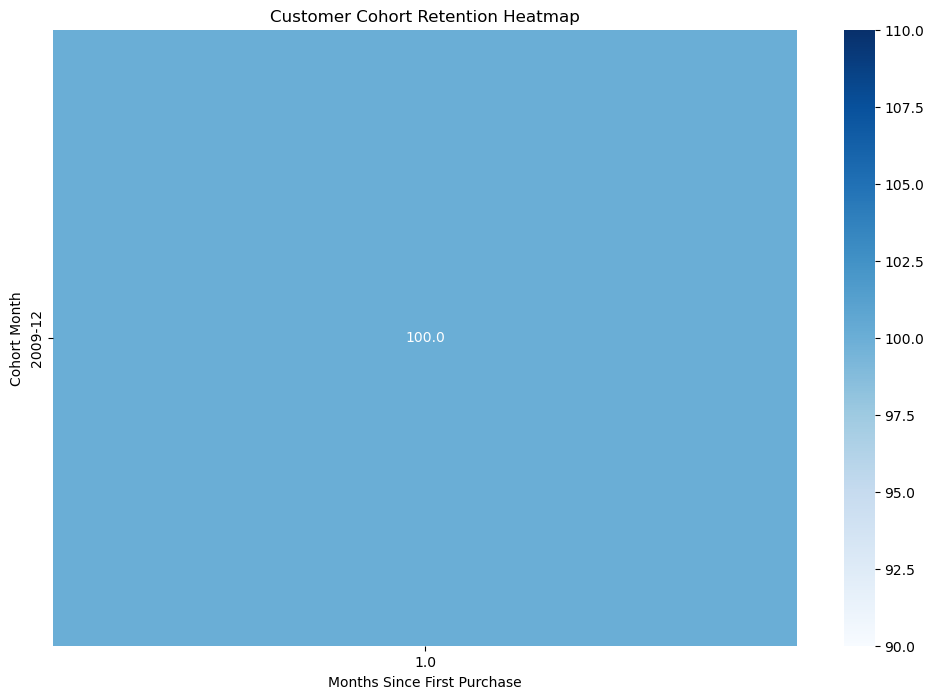

In [18]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()